## GROUP3 Final Project
### Cluster-Aware PageRank for Global Event Networks using GDELT data
#### Almodal, Mendoza, Ramos, ReyesN

In [1]:
from pathlib import Path
from functools import reduce

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, sum as spark_sum, desc,
    to_date, year, month, lit, row_number,
)
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm

### CONFIG

In [2]:
DATA_DIRS = [
    "/Users/erickaeuniced.mendoza/BigData/unzipped_aug2025",
    "/Users/erickaeuniced.mendoza/BigData/unzipped_sep2025",
    "/Users/erickaeuniced.mendoza/BigData/unzippedOct25",
    "/Users/erickaeuniced.mendoza/BigData/unzippedNov25",
    "/Users/erickaeuniced.mendoza/BigData/unzippedDec25",
    "/Users/erickaeuniced.mendoza/BigData/unzippedJan26",
    "/Users/erickaeuniced.mendoza/BigData/unzippedFeb26",
    "/Users/erickaeuniced.mendoza/BigData/unzippedMar26",
    "/Users/erickaeuniced.mendoza/BigData/unzippedApr26",
    "/Users/erickaeuniced.mendoza/BigData/unzippedMay2025",
    "/Users/erickaeuniced.mendoza/BigData/unzippedJun2025",
    "/Users/erickaeuniced.mendoza/BigData/unzippedJul2025"
]

FEATURE_COLS = [
    "event_count", "avg_goldstein", "avg_mentions",
    "avg_sources",  "avg_articles",  "avg_tone",
]

K_RANGE = range(2, 11)

# 1 - Load GDELT Data to Spark

In [3]:
try:
    spark.stop()
except Exception:
    pass

spark = SparkSession.builder \
    .appName("GDELT_Cluster_PageRank_Group3") \
    .master("local[*]") \
    .config("spark.driver.memory","24g") \
    .config("spark.sql.shuffle.partitions","64") \
    .config("spark.driver.maxResultSize","4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/23 02:37:01 WARN Utils: Your hostname, eckas-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.121 instead (on interface en0)
26/05/23 02:37:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 02:37:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/23 02:37:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


In [4]:
dfs = []
for path in DATA_DIRS:


    df = spark.read \
        .option("header", False) \
        .option("sep", "\t") \
        .csv(path)

    # rename columns safely
    df = df.toDF(*[f"col_{i}" for i in range(len(df.columns))])

    for c in df.columns:
        df = df.withColumn(c, df[c].cast("string"))

    dfs.append(df)

all_cols = sorted(set(c for df in dfs for c in df.columns))

aligned = []

for df in dfs:
    missing = set(all_cols) - set(df.columns)

    for c in missing:
        df = df.withColumn(c, df[c].cast("string")) if c in df.columns else df.withColumn(c, spark.createDataFrame([(None,)], ["tmp"]).select("tmp"))

    df = df.select(all_cols)
    aligned.append(df)

merged_df = reduce(lambda a, b: a.unionByName(b), aligned)


merged_df.write \
    .mode("overwrite") \
    .option("header", True) \

print("SUCCESS: datasets merged safely")

SUCCESS: datasets merged safely


In [5]:
print("Number of Columns: ", len(merged_df.columns))
print("Initial row count: ", merged_df.count())
merged_df.show(5)

Number of Columns:  58


Initial row count:  38805117
+----------+--------+------+------+------+------+------+------+---------+------+------+------+------+------+------+------+------+------+------+------+------+------+------+-----+------+------+------+------+-----------------+------+------+------+------+------+---------+------+------+------+--------------------+------+------+--------+--------+--------+------+-----+--------------------+------+------+--------+--------+--------+--------+--------------------+-----+-----+-----+-----+
|     col_0|   col_1|col_10|col_11|col_12|col_13|col_14|col_15|   col_16|col_17|col_18|col_19| col_2|col_20|col_21|col_22|col_23|col_24|col_25|col_26|col_27|col_28|col_29|col_3|col_30|col_31|col_32|col_33|           col_34|col_35|col_36|col_37|col_38|col_39|    col_4|col_40|col_41|col_42|              col_43|col_44|col_45|  col_46|  col_47|  col_48|col_49|col_5|              col_50|col_51|col_52|  col_53|  col_54|  col_55|  col_56|              col_57|col_6|col_7|col_8|col_9|
+--------

# 2 PREPROCESSING

In [6]:
renamed_df = merged_df.select(
    col("col_0").alias("GlobalEventID"),
    col("col_1").alias("Date"),
    col("col_7").alias("country_1"),
    col("col_17").alias("country_2"),
    col("col_26").alias("EventCode"),
    col("col_30").cast("double").alias("GoldsteinScale"),
    col("col_31").cast("int").alias("NumMentions"),
    col("col_32").cast("int").alias("NumSources"),
    col("col_33").cast("int").alias("NumArticles"),
    col("col_34").cast("double").alias("AvgTone")
)


print("Missing values per column:")
missing_counts = renamed_df.select([
    spark_sum(col(c).isNull().try_cast("int")).alias(c)
    for c in renamed_df.columns
]).show()

Missing values per column:


+-------------+----+---------+---------+---------+--------------+-----------+----------+-----------+-------+
|GlobalEventID|Date|country_1|country_2|EventCode|GoldsteinScale|NumMentions|NumSources|NumArticles|AvgTone|
+-------------+----+---------+---------+---------+--------------+-----------+----------+-----------+-------+
|            0|   0| 16621500| 21146116|        0|           185|          0|         0|          0|      0|
+-------------+----+---------+---------+---------+--------------+-----------+----------+-----------+-------+



In [7]:
clean_df = renamed_df.dropna(
    subset=["country_1", "country_2", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone"]
)

original_count = renamed_df.count()
clean_count = clean_df.count()

print("Original rows:", original_count)
print("Clean rows:", clean_count)
print("Removed rows:", original_count - clean_count)


clean_df = clean_df.withColumn(
    "EventDate",
    to_date(col("Date").cast("string"), "yyyyMMdd")
).withColumn(
    "Year",
    year(col("EventDate"))
).withColumn(
    "Month",
    month(col("EventDate"))
).filter(
    (col("country_1") != "") &
    (col("country_2") != "") &
    (col("country_1") != col("country_2")) &
    (col("EventDate") >= "2025-01-01") 
)

clean_df.show(5)

Original rows: 38805117
Clean rows: 10219525
Removed rows: 28585592
+-------------+--------+---------+---------+---------+--------------+-----------+----------+-----------+-----------------+----------+----+-----+
|GlobalEventID|    Date|country_1|country_2|EventCode|GoldsteinScale|NumMentions|NumSources|NumArticles|          AvgTone| EventDate|Year|Month|
+-------------+--------+---------+---------+---------+--------------+-----------+----------+-----------+-----------------+----------+----+-----+
|   1255133436|20250702|      CAN|      FRA|      020|           3.0|          1|         1|          1| -0.6440281030445|2025-07-02|2025|    7|
|   1255133437|20250702|      CAN|      FRA|      020|           3.0|         10|         2|         10|-1.10051731621336|2025-07-02|2025|    7|
|   1255133438|20250702|      CAN|      FRA|      020|           3.0|          4|         2|          4|-1.10051731621336|2025-07-02|2025|    7|
|   1255133439|20250702|      CAN|      ISR|      020|        

# 3 EDA

In [8]:
print("Date range:")
clean_df.selectExpr("min(EventDate) as min_date", "max(EventDate) as max_date").show()

print("Top Actor1 countries:")
clean_df.groupBy("country_1").count().orderBy(desc("count")).show(10)

print("Top Actor2 countries:")
clean_df.groupBy("country_2").count().orderBy(desc("count")).show(10)

print("Most common event codes:")
clean_df.groupBy("EventCode").count().orderBy(desc("count")).show(10)


Date range:


+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2025-01-01|2026-04-30|
+----------+----------+

Top Actor1 countries:


+---------+-------+
|country_1|  count|
+---------+-------+
|      USA|1202534|
|      ISR| 481344|
|      RUS| 392689|
|      GBR| 384444|
|      CHN| 325619|
|      IRN| 300265|
|      UKR| 283055|
|      FRA| 187161|
|      PSE| 185903|
|      EUR| 173636|
+---------+-------+
only showing top 10 rows
Top Actor2 countries:


+---------+-------+
|country_2|  count|
+---------+-------+
|      USA|1137285|
|      ISR| 509716|
|      RUS| 415719|
|      IRN| 348631|
|      GBR| 339549|
|      UKR| 328122|
|      CHN| 316346|
|      PSE| 271604|
|      EUR| 185801|
|      FRA| 160330|
+---------+-------+
only showing top 10 rows
Most common event codes:


+---------+------+
|EventCode| count|
+---------+------+
|      042|736770|
|      043|706398|
|      040|598175|
|      010|436539|
|      051|411617|
|      046|403710|
|      190|328664|
|      036|321101|
|      020|314011|
|      057|192968|
+---------+------+
only showing top 10 rows


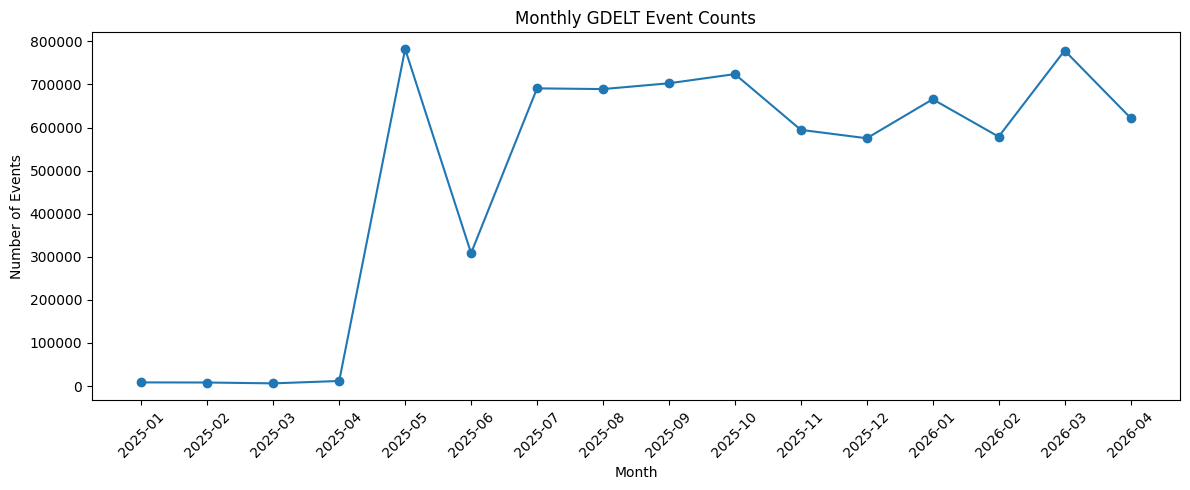

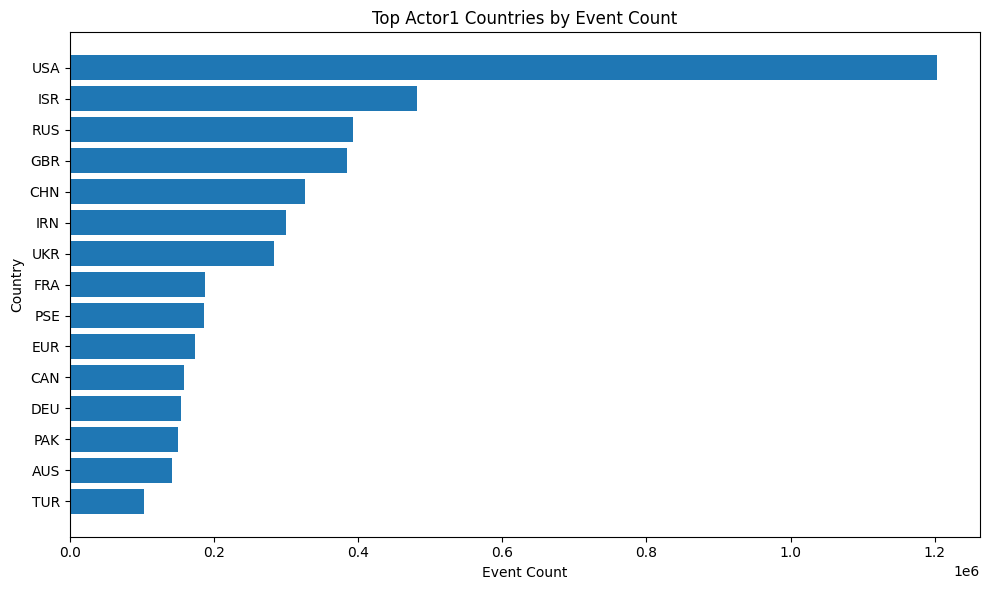

In [9]:
#Monthly event counts
monthly_pd = clean_df.groupBy("Year", "Month").count().orderBy("Year", "Month").toPandas()
monthly_pd["year_month"] = monthly_pd["Year"].astype(str) + "-" + monthly_pd["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(monthly_pd["year_month"], monthly_pd["count"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.title("Monthly GDELT Event Counts")
plt.tight_layout()
plt.show()

# Top countries
country_pd = clean_df.groupBy("country_1").count().orderBy(desc("count")).limit(15).toPandas()
plt.figure(figsize=(10, 6))
plt.barh(country_pd["country_1"][::-1], country_pd["count"][::-1])
plt.xlabel("Event Count")
plt.ylabel("Country")
plt.title("Top Actor1 Countries by Event Count")
plt.tight_layout()
plt.show()

# 4 AGGREGATE

In [10]:
df_grouped = clean_df.groupBy("country_1").agg(
    count("*").alias("event_count"),
    avg("GoldsteinScale").alias("avg_goldstein"),
    avg("NumMentions").alias("avg_mentions"),
    avg("NumSources").alias("avg_sources"),
    avg("NumArticles").alias("avg_articles"),
    avg("AvgTone").alias("avg_tone")
).withColumnRenamed("Actor1Country", "country")

print("Aggregated data:")
df_grouped.show(5)

Aggregated data:


+---------+-----------+------------------+------------------+------------------+------------------+--------------------+
|country_1|event_count|     avg_goldstein|      avg_mentions|       avg_sources|      avg_articles|            avg_tone|
+---------+-----------+------------------+------------------+------------------+------------------+--------------------+
|      JOR|      36964|0.8268261010713123|6.8575911697868195| 1.906665945244021| 6.756438697110703| -1.7836576761504974|
|      BOL|       3832|1.6366388308977031|5.1184759916492695| 1.562108559498956| 5.059759916492693| -1.1541764479785301|
|      SAF|        979|2.3452502553626147|  6.65679264555669| 1.146067415730337|6.4974463738508685|  0.3688187796317284|
|      KGZ|       8025|3.0588785046728986| 4.962866043613707|1.3251090342679128| 4.905794392523364|  1.0633147946764263|
|      ETH|      15391| 1.700032486518094| 6.989539341173413|1.7850691962835423| 6.900006497303619|-0.46057526546124744|
+---------+-----------+---------

# 5 DIMENSIONALITY REDUCTION - PCA

In [11]:
assembler = VectorAssembler(
    inputCols=[
        "event_count",
        "avg_goldstein",
        "avg_mentions",
        "avg_sources",
        "avg_articles",
        "avg_tone"
    ],
    outputCol="features"
)
final_df = assembler.transform(df_grouped)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(final_df)
scaled_df    = scaler_model.transform(final_df)

print("Scaling complete. Sample:")
scaled_df.select("country_1", "scaled_features").show(5, truncate=80)

Scaling complete. Sample:


+---------+--------------------------------------------------------------------------------+
|country_1|                                                                 scaled_features|
+---------+--------------------------------------------------------------------------------+
|      JOR|[0.015384826773102264,-0.9123360496013847,-0.05587964825886971,-0.00783713665...|
|      BOL|[-0.30586715578039647,0.024552139099123325,-0.9523327800953785,-0.67230557779...|
|      SAF|[-0.33353019774059,0.8443585579260338,-0.15938427416123271,-1.474628272626481...|
|      KGZ|[-0.26521130757181205,1.669969039555731,-1.032544273281693,-1.129351955553616...|
|      ETH|[-0.19378965770192574,0.09789349939365036,0.012135025505455616,-0.24233276952...|
+---------+--------------------------------------------------------------------------------+
only showing top 5 rows


Explained variance per component:
  PC1: 0.5354  (cumulative: 0.5354)
  PC2: 0.2642  (cumulative: 0.7996)
  PC3: 0.1376  (cumulative: 0.9372)
  PC4: 0.0371  (cumulative: 0.9742)
  PC5: 0.0252  (cumulative: 0.9994)
  PC6: 0.0006  (cumulative: 1.0000)


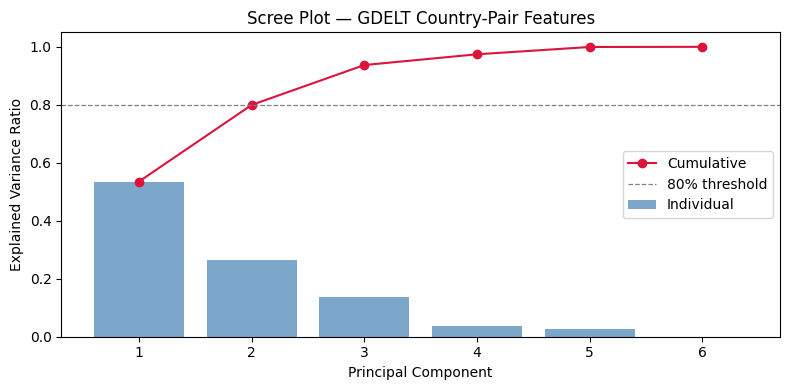

In [12]:
N_FEATURES   = len(FEATURE_COLS)

pca_full       = PCA(k=N_FEATURES, inputCol="scaled_features", outputCol="pca_all")
pca_full_model = pca_full.fit(scaled_df)

ev     = pca_full_model.explainedVariance
cum_ev = np.cumsum(ev)

print("Explained variance per component:")
for i, (v, c) in enumerate(zip(ev, cum_ev), 1):
    print(f"  PC{i}: {v:.4f}  (cumulative: {c:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, N_FEATURES + 1), ev, alpha=0.7, color="steelblue", label="Individual")
ax.plot(range(1, N_FEATURES + 1), cum_ev, marker="o", color="crimson", label="Cumulative")
ax.axhline(0.80, linestyle="--", color="grey", linewidth=0.9, label="80% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot — GDELT Country-Pair Features")
ax.set_xticks(range(1, N_FEATURES + 1))
ax.legend()
plt.tight_layout()
plt.show()

PC1 explains 53.5%, PC2 explains 26.4%,  PC3 explains 13.8%Combined: 93.7%


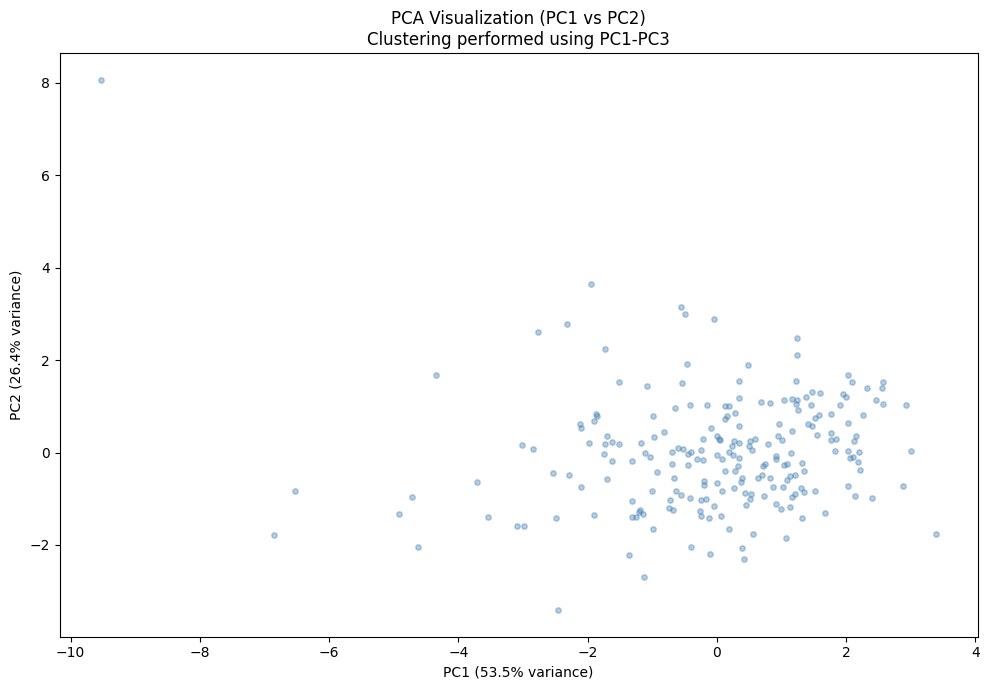

PCA scatter saved.


In [13]:
K_PCA = 3

pca       = PCA(k=K_PCA, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
pca_df    = pca_model.transform(scaled_df)

var_pc1 = pca_model.explainedVariance[0]
var_pc2 = pca_model.explainedVariance[1]
var_pc3 = pca_model.explainedVariance[2]
print(f"PC1 explains {var_pc1:.1%}, PC2 explains {var_pc2:.1%},  PC3 explains {var_pc3:.1%}"
      f"Combined: {(var_pc1+var_pc2+var_pc3):.1%}")

# Pull to pandas for matplotlib
pca_pd = pca_df.select("country_1", "pca_features").toPandas()
pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda v: float(v[0]))
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda v: float(v[1]))
pca_pd["PC3"] = pca_pd["pca_features"].apply(lambda v: float(v[2]))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pca_pd["PC1"], pca_pd["PC2"], alpha=0.4, s=15, color="steelblue")
ax.set_xlabel(f"PC1 ({var_pc1:.1%} variance)")
ax.set_ylabel(f"PC2 ({var_pc2:.1%} variance)")
ax.set_title("PCA Visualization (PC1 vs PC2)\nClustering performed using PC1-PC3")
plt.tight_layout()
plt.savefig("/Users/erickaeuniced.mendoza/BigData/processed/pca_scatter(2).png", dpi=150)
plt.show()
print("PCA scatter saved.")

# 6 K-MEANS

  k= 2  WCSS=      821.02  Silhouette=0.5371


  k= 3  WCSS=      659.70  Silhouette=0.4012


  k= 4  WCSS=      548.49  Silhouette=0.4213


  k= 5  WCSS=      488.07  Silhouette=0.3594


  k= 6  WCSS=      388.74  Silhouette=0.4405


  k= 7  WCSS=      331.32  Silhouette=0.4373


  k= 8  WCSS=      309.53  Silhouette=0.4590


  k= 9  WCSS=      222.72  Silhouette=0.4760


  k=10  WCSS=      259.45  Silhouette=0.4325


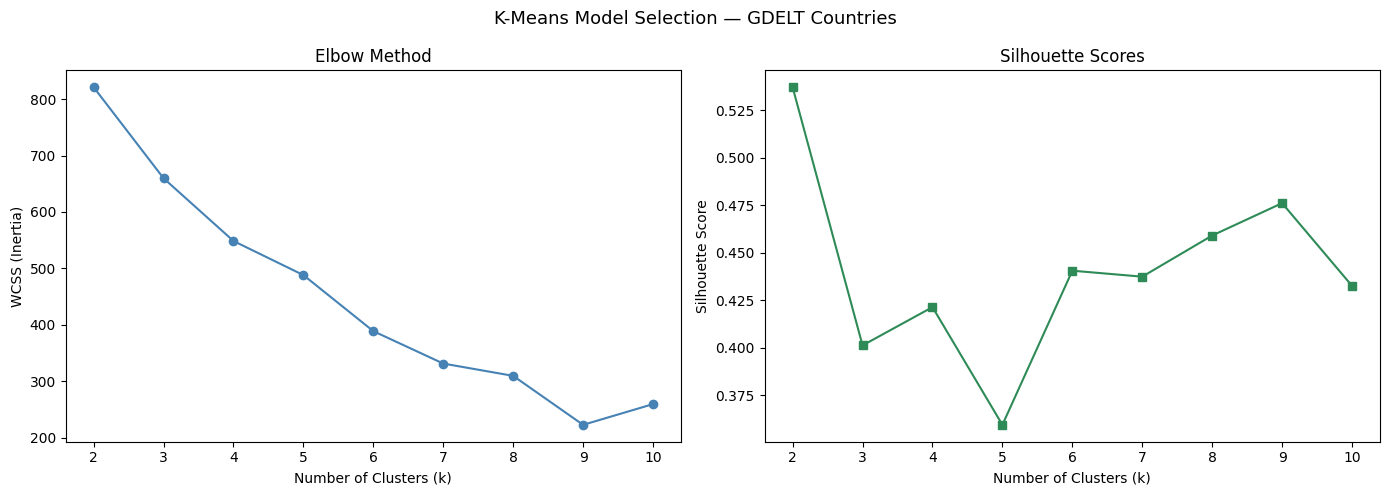

In [14]:
evaluator = ClusteringEvaluator(
    featuresCol="pca_features", predictionCol="prediction",
    metricName="silhouette", distanceMeasure="squaredEuclidean",
)

wcss_list, sil_list = [], []
for k in K_RANGE:
    km          = KMeans(featuresCol="pca_features", predictionCol="prediction",
                         k=k, seed=42, maxIter=100)
    km_model    = km.fit(pca_df)
    predictions = km_model.transform(pca_df)
    wcss        = km_model.summary.trainingCost
    sil         = evaluator.evaluate(predictions)
    wcss_list.append(wcss)
    sil_list.append(sil)
    print(f"  k={k:2d}  WCSS={wcss:>12,.2f}  Silhouette={sil:.4f}")

k_vals = list(K_RANGE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_vals, wcss_list, marker="o", color="steelblue")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(k_vals)
axes[1].plot(k_vals, sil_list, marker="s", color="seagreen")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")
axes[1].set_xticks(k_vals)
plt.suptitle("K-Means Model Selection — GDELT Countries", fontsize=13)
plt.tight_layout()
plt.show()



In [15]:
K_FINAL = 2   

km_final = KMeans(
    featuresCol="pca_features",
    predictionCol="cluster",
    k=K_FINAL,
    seed=42,
    maxIter=200
)
km_final_model = km_final.fit(pca_df)
clustered_df   = km_final_model.transform(pca_df)

final_eval = ClusteringEvaluator(
    featuresCol="pca_features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)
final_sil = final_eval.evaluate(clustered_df)
silhouette_pca = final_sil
print(f"Final model  k={K_FINAL}  Silhouette Score = {final_sil:.4f}")

print("\nCluster centres (PC1, PC2):")
for i, c in enumerate(km_final_model.clusterCenters()):
    print(f"  Cluster {i}: PC1={c[0]:.4f}  PC2={c[1]:.4f}")

Final model  k=2  Silhouette Score = 0.5371

Cluster centres (PC1, PC2):
  Cluster 0: PC1=-2.0588  PC2=-0.2108
  Cluster 1: PC1=0.8881  PC2=0.0910


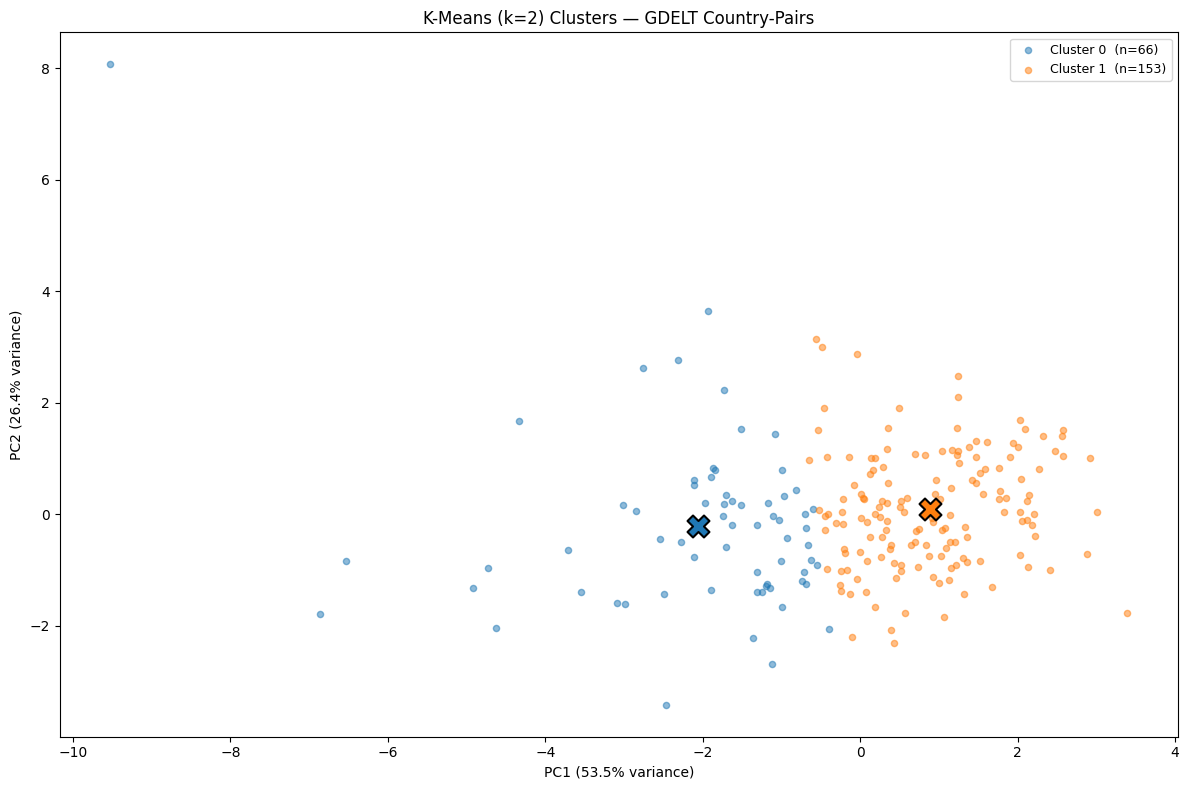

In [16]:
cluster_pd = clustered_df.select(
    "country_1", "pca_features", "cluster"
).toPandas()

cluster_pd["PC1"] = cluster_pd["pca_features"].apply(lambda v: float(v[0]))
cluster_pd["PC2"] = cluster_pd["pca_features"].apply(lambda v: float(v[1]))
cluster_pd["PC3"] = cluster_pd["pca_features"].apply(lambda v: float(v[2]))


COLORS  = plt.cm.tab10.colors
centres = km_final_model.clusterCenters()

fig, ax = plt.subplots(figsize=(12, 8))
for c_id in range(K_FINAL):
    mask = cluster_pd["cluster"] == c_id
    ax.scatter(
        cluster_pd.loc[mask, "PC1"],
        cluster_pd.loc[mask, "PC2"],
        s=20, alpha=0.5,
        color=COLORS[c_id],
        label=f"Cluster {c_id}  (n={mask.sum():,})"
    )
    ax.scatter(
        centres[c_id][0],
        centres[c_id][1],
        s=250,
        marker="X",
        color=COLORS[c_id % len(COLORS)],
        edgecolors="black",
        linewidths=1.5,
        zorder=5
    )

ax.set_xlabel(f"PC1 ({var_pc1:.1%} variance)")
ax.set_ylabel(f"PC2 ({var_pc2:.1%} variance)")
ax.set_title(f"K-Means (k={K_FINAL}) Clusters — GDELT Country-Pairs")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


In [17]:
feature_cols = [
    "event_count", "avg_goldstein", "avg_mentions",
    "avg_sources", "avg_articles", "avg_tone"
]

profile_input = clustered_df.select(
    "country_1", "cluster"
).join(
    df_grouped.select(
        "country_1", *feature_cols
    ),
    on="country_1", how="inner"
)


profile_df = profile_input.groupBy("cluster").agg(
    count("*").alias("num_countries"),
    *[avg(f).alias(f"mean_{f}") for f in feature_cols]
).orderBy("cluster")

print("Cluster profiles (mean of original features):")
profile_df.show(truncate=False)

print("\nCluster sizes:")
clustered_df.groupBy("cluster").count().orderBy("cluster").show()

Cluster profiles (mean of original features):


+-------+-------------+------------------+------------------+-----------------+------------------+-----------------+-------------------+
|cluster|num_countries|mean_event_count  |mean_avg_goldstein|mean_avg_mentions|mean_avg_sources  |mean_avg_articles|mean_avg_tone      |
+-------+-------------+------------------+------------------+-----------------+------------------+-----------------+-------------------+
|0      |66           |89277.71212121213 |0.9859035275831822|8.78926427665738 |2.45147153488681  |8.609590403928957|-1.9932891341944787|
|1      |153          |12126.143790849674|1.8869715988973343|6.179490183503309|1.6774687458028987|6.056517299833105|-0.4134130498709156|
+-------+-------------+------------------+------------------+-----------------+------------------+-----------------+-------------------+


Cluster sizes:


+-------+-----+
|cluster|count|
+-------+-----+
|      0|   66|
|      1|  153|
+-------+-----+



Without PCA

k=2
   WCSS       : 1176.04
   Silhouette : 0.9147


k=3
   WCSS       : 741.15
   Silhouette : 0.3585


k=4
   WCSS       : 630.55
   Silhouette : 0.3916


k=5
   WCSS       : 541.84
   Silhouette : 0.4003


k=6
   WCSS       : 467.91
   Silhouette : 0.3880


k=7
   WCSS       : 403.46
   Silhouette : 0.4028


k=8
   WCSS       : 376.01
   Silhouette : 0.3365


k=9
   WCSS       : 301.49
   Silhouette : 0.3423


k=10
   WCSS       : 338.94
   Silhouette : 0.3270


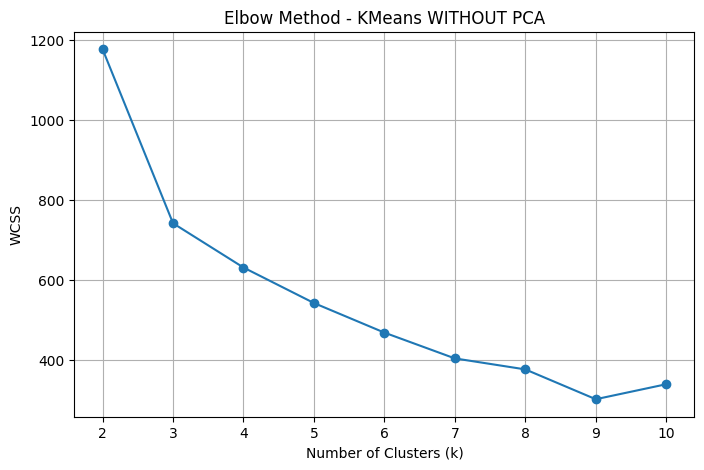

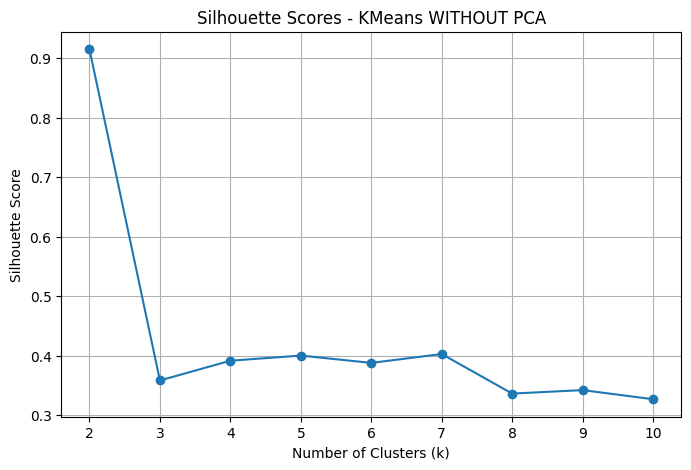

Final Silhouette Score (Without PCA): 0.3585


In [18]:
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(final_df)
scaled_df = scaler_model.transform(final_df)


K_RANGE = range(2, 11)

wcss_list = []
sil_list = []

evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in K_RANGE:

    km = KMeans(
        featuresCol="scaled_features",
        predictionCol="prediction",
        k=k,
        seed=42,
        maxIter=100
    )

    km_model = km.fit(scaled_df)

    predictions = km_model.transform(scaled_df)

    wcss = km_model.summary.trainingCost
    silhouette = evaluator.evaluate(predictions)

    wcss_list.append(wcss)
    sil_list.append(silhouette)

    print(f"k={k}")
    print(f"   WCSS       : {wcss:.2f}")
    print(f"   Silhouette : {silhouette:.4f}")


plt.figure(figsize=(8,5))
plt.plot(list(K_RANGE), wcss_list, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method - KMeans WITHOUT PCA")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(list(K_RANGE), sil_list, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores - KMeans WITHOUT PCA")
plt.grid(True)
plt.show()


K_FINAL = 3

km_final = KMeans(
    featuresCol="scaled_features",
    predictionCol="prediction",
    k=K_FINAL,
    seed=42,
    maxIter=200
)

km_final_model = km_final.fit(scaled_df)

clustered_no_pca = km_final_model.transform(scaled_df)

final_silhouette = evaluator.evaluate(clustered_no_pca)

silhouette_no_pca = final_silhouette

print(f"Final Silhouette Score (Without PCA): {final_silhouette:.4f}")

Comparison

In [19]:
print("COMPARISON OF K-MEANS RESULTS")

print(f"Without PCA Silhouette Score : {silhouette_no_pca:.4f}")
print(f"With PCA Silhouette Score    : {silhouette_pca:.4f}")

if silhouette_pca > silhouette_no_pca:
    print("PCA improved clustering performance.")
else:
    print("PCA did not improve clustering performance.")

COMPARISON OF K-MEANS RESULTS
Without PCA Silhouette Score : 0.3585
With PCA Silhouette Score    : 0.5371
PCA improved clustering performance.


# 7 COUNTRY INTERACTION GRAPH

Total directed edges: 19098


+---------+---------+------+--------------------+-------------------+------------------+-----------+-----------+
|country_2|country_1|weight|avg_goldstein       |avg_tone           |avg_mentions      |cluster_src|cluster_dst|
+---------+---------+------+--------------------+-------------------+------------------+-----------+-----------+
|USA      |FRA      |29620 |0.9249358541526004  |-1.244872518722377 |7.085010128291695 |0          |0          |
|CAN      |USA      |46691 |1.2919898909854144  |-0.7358809840332927|7.695294596389026 |0          |0          |
|USA      |WST      |4670  |2.0028693790149896  |-1.7843754588750445|10.016488222698072|0          |0          |
|SAU      |IRN      |5519  |-0.8951259286102561 |-3.0647932867146146|8.172313824968292 |0          |1          |
|USA      |SLV      |5688  |-0.18707805907172986|-5.205912025827464 |9.07823488045007  |0          |0          |
|SSD      |UGA      |521   |-0.758925143953935  |-3.4715547433220633|4.940499040307102 |1       

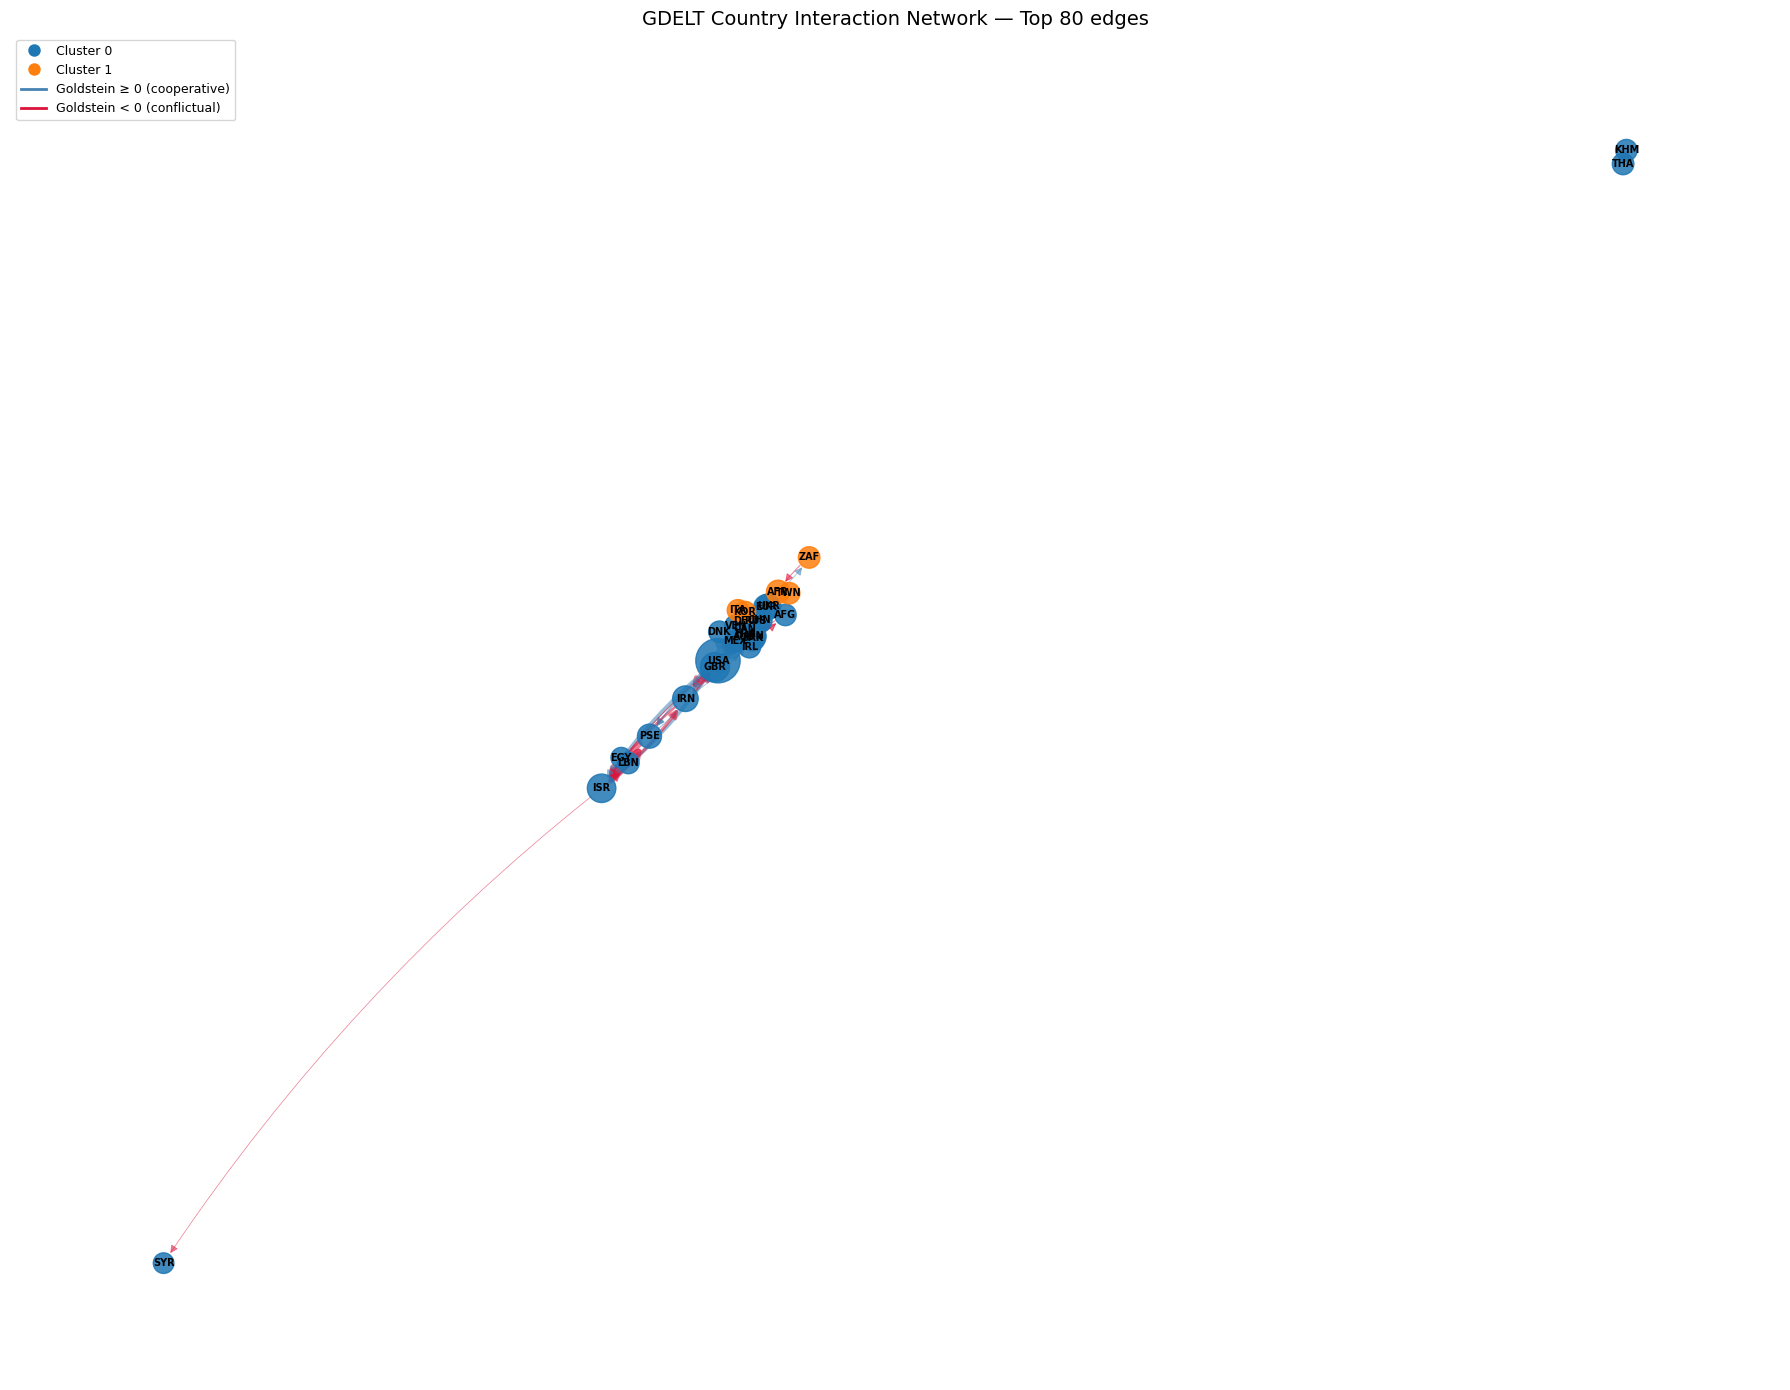

+-------+----------+------------+---------+-----------+-------+
|country|out_degree|out_strength|in_degree|in_strength|cluster|
+-------+----------+------------+---------+-----------+-------+
|USA    |213       |1202531     |211      |1137277    |0      |
|ISR    |175       |481284      |185      |509667     |0      |
|RUS    |180       |392650      |181      |415688     |0      |
|GBR    |199       |384419      |199      |339533     |0      |
|CHN    |203       |325603      |202      |316328     |0      |
|IRN    |159       |300217      |166      |348597     |0      |
|UKR    |151       |282997      |151      |328063     |0      |
|FRA    |201       |187144      |202      |160311     |0      |
|PSE    |137       |185817      |158      |271547     |0      |
|EUR    |187       |173600      |188      |185761     |0      |
|CAN    |181       |158744      |178      |138739     |0      |
|DEU    |176       |154722      |179      |123941     |0      |
|PAK    |148       |150756      |141    

Done. Nodes: 218 | Edges: 19098


In [20]:
edges_df = (
    clean_df
    .groupBy("country_1", "country_2")
    .agg(
        count("*").alias("weight"),
        avg("GoldsteinScale").alias("avg_goldstein"),
        avg("AvgTone").alias("avg_tone"),
        avg("NumMentions").alias("avg_mentions"),
    )
    .filter(col("weight") >= 5)
    .orderBy(desc("weight"))
)
print(f"Total directed edges: {edges_df.count()}")

clusters = clustered_df.select(col("country_1").alias("country"), col("cluster"))

network_df = (
    edges_df
    .join(clusters.withColumnRenamed("country", "country_1").withColumnRenamed("cluster", "cluster_src"), on="country_1", how="left")
    .join(clusters.withColumnRenamed("country", "country_2").withColumnRenamed("cluster", "cluster_dst"), on="country_2", how="left")
)
network_df.show(10, truncate=False)

network_pd = network_df.orderBy(desc("weight")).limit(80).toPandas()

TOP_N    = 80
top_edges = network_pd.nlargest(TOP_N, "weight")

G = nx.DiGraph()
for _, r in top_edges.iterrows():
    G.add_node(r["country_1"], cluster=int(r["cluster_src"]) if pd.notna(r["cluster_src"]) else -1)
    G.add_node(r["country_2"], cluster=int(r["cluster_dst"]) if pd.notna(r["cluster_dst"]) else -1)
    G.add_edge(r["country_1"], r["country_2"], weight=r["weight"], goldstein=r["avg_goldstein"])

pos         = nx.spring_layout(G, seed=42, k=2.5 / np.sqrt(G.number_of_nodes()))
clusters_v  = [G.nodes[n].get("cluster", -1) for n in G.nodes]
color_map   = {c: cm.tab10.colors[i % 10] for i, c in enumerate(sorted(set(clusters_v)))}
weights     = np.array([d["weight"] for *_, d in G.edges(data=True)], dtype=float)
edge_widths = 0.5 + 4.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-9)
edge_colors = ["crimson" if d.get("goldstein", 0) < 0 else "steelblue" for *_, d in G.edges(data=True)]

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_nodes(G, pos, node_color=[color_map[c] for c in clusters_v],
                       node_size=[200 + 20 * G.degree(n) for n in G.nodes], alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.55,
                       arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.08", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)

legend = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=color_map[c],
          markersize=10, label=f"Cluster {c}") for c in sorted(set(clusters_v))]
legend += [plt.Line2D([0],[0], color="steelblue", lw=2, label="Goldstein ≥ 0 (cooperative)"),
           plt.Line2D([0],[0], color="crimson",   lw=2, label="Goldstein < 0 (conflictual)")]
ax.legend(handles=legend, loc="upper left", fontsize=9)
ax.set_title(f"GDELT Country Interaction Network — Top {TOP_N} edges", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

node_summary = (
    network_df.groupBy("country_1").agg(count("*").alias("out_degree"), spark_sum("weight").alias("out_strength"))
    .withColumnRenamed("country_1", "country")
    .join(network_df.groupBy("country_2").agg(count("*").alias("in_degree"), spark_sum("weight").alias("in_strength"))
          .withColumnRenamed("country_2", "country"), on="country", how="outer")
    .join(clusters, on="country", how="left")
    .fillna(0, subset=["out_degree", "out_strength", "in_degree", "in_strength"])
    .orderBy(desc("out_strength"))
)
node_summary.show(15, truncate=False)
print("Done. Nodes:", node_summary.count(), "| Edges:", network_df.count())

# 8 PAGERANK

In [21]:
pr_edges = network_df.select(
    col("country_1").alias("src"),
    col("country_2").alias("dst"),
    col("weight").cast("double").alias("weight")
).filter(
    (col("src").isNotNull()) &
    (col("dst").isNotNull()) &
    (col("src") != col("dst")) &
    (col("weight") > 0)
)

nodes = pr_edges.select(col("src").alias("country")) \
    .union(pr_edges.select(col("dst").alias("country"))) \
    .distinct()

N = nodes.count()
print("Number of PageRank nodes:", N)

# Normalize outgoing edge weights
out_weight = pr_edges.groupBy("src").agg(
    spark_sum("weight").alias("total_out_weight")
)

weighted_edges = pr_edges.join(out_weight, on="src", how="inner") \
    .withColumn("prob", col("weight") / col("total_out_weight")) \
    .select("src", "dst", "prob") \
    .persist()

# ==============================
# 2. Weighted PageRank
# ==============================

damping = 0.85
iterations = 10

ranks = nodes.withColumn("pagerank", lit(1.0 / N))

for i in range(iterations):
    contribs = weighted_edges.join(
        ranks,
        weighted_edges.src == ranks.country,
        "inner"
    ).select(
        col("dst").alias("country"),
        (col("pagerank") * col("prob")).alias("contribution")
    )

    ranks = contribs.groupBy("country").agg(
        spark_sum("contribution").alias("sum_contribution")
    ).withColumn(
        "pagerank",
        lit((1 - damping) / N) + lit(damping) * col("sum_contribution")
    ).select("country", "pagerank")

    # keep countries that may not receive contributions in this iteration
    ranks = nodes.join(ranks, on="country", how="left").fillna(
        (1 - damping) / N,
        subset=["pagerank"]
    )

    print(f"Finished PageRank iteration {i + 1}")

pagerank_df = ranks.persist()

print("Top PageRank countries:")
pagerank_df.orderBy(desc("pagerank")).show(20, truncate=False)

Number of PageRank nodes: 218
Finished PageRank iteration 1
Finished PageRank iteration 2
Finished PageRank iteration 3
Finished PageRank iteration 4
Finished PageRank iteration 5
Finished PageRank iteration 6
Finished PageRank iteration 7
Finished PageRank iteration 8
Finished PageRank iteration 9
Finished PageRank iteration 10
Top PageRank countries:


+-------+--------------------+
|country|pagerank            |
+-------+--------------------+
|USA    |0.12752764246239942 |
|ISR    |0.05458787074198169 |
|RUS    |0.042374376537478234|
|CHN    |0.03712387580061452 |
|GBR    |0.03668208148768053 |
|IRN    |0.03462265510784473 |
|UKR    |0.03161804275335473 |
|PSE    |0.02708989999367202 |
|EUR    |0.0194617740242328  |
|FRA    |0.018259975467418157|
|AFR    |0.016380645778687947|
|AUS    |0.015602280460166644|
|PAK    |0.015115070485763158|
|CAN    |0.014693566704549276|
|DEU    |0.01303697184701729 |
|JPN    |0.01164932469534564 |
|TUR    |0.01019501138643753 |
|NGA    |0.008686315493101   |
|ITA    |0.008613315932688029|
|LBN    |0.008594356792879388|
+-------+--------------------+
only showing top 20 rows


In [22]:
country_clusters = clusters.select("country", "cluster").dropDuplicates(["country"])

ranked_clusters = pagerank_df.join(
    country_clusters,
    on="country",
    how="left"
)

print("Top PageRank countries with clusters:")
ranked_clusters.orderBy(desc("pagerank")).show(20, truncate=False)

print("PageRank summary per cluster:")
cluster_pagerank_summary = ranked_clusters.groupBy("cluster").agg(
    count("*").alias("num_countries"),
    avg("pagerank").alias("mean_pagerank"),
    spark_sum("pagerank").alias("total_pagerank")
).orderBy("cluster")

cluster_pagerank_summary.show(truncate=False)

print("Top countries within each cluster:")
w = Window.partitionBy("cluster").orderBy(desc("pagerank"))

top_by_cluster = ranked_clusters.withColumn(
    "rank_in_cluster",
    row_number().over(w)
).filter(
    col("rank_in_cluster") <= 10
).orderBy("cluster", "rank_in_cluster")

top_by_cluster.show(100, truncate=False)

Top PageRank countries with clusters:


+-------+--------------------+-------+
|country|pagerank            |cluster|
+-------+--------------------+-------+
|USA    |0.12752764246239942 |0      |
|ISR    |0.05458787074198169 |0      |
|RUS    |0.042374376537478234|0      |
|CHN    |0.03712387580061452 |0      |
|GBR    |0.03668208148768053 |0      |
|IRN    |0.03462265510784473 |0      |
|UKR    |0.03161804275335473 |0      |
|PSE    |0.02708989999367202 |0      |
|EUR    |0.0194617740242328  |0      |
|FRA    |0.018259975467418157|0      |
|AFR    |0.016380645778687947|1      |
|AUS    |0.015602280460166644|0      |
|PAK    |0.015115070485763158|0      |
|CAN    |0.014693566704549276|0      |
|DEU    |0.01303697184701729 |0      |
|JPN    |0.01164932469534564 |0      |
|TUR    |0.01019501138643753 |0      |
|NGA    |0.008686315493101   |1      |
|ITA    |0.008613315932688029|1      |
|LBN    |0.008594356792879388|0      |
+-------+--------------------+-------+
only showing top 20 rows
PageRank summary per cluster:


+-------+-------------+---------------------+------------------+
|cluster|num_countries|mean_pagerank        |total_pagerank    |
+-------+-------------+---------------------+------------------+
|0      |66           |0.010223156494673508 |0.6747283286484516|
|1      |152          |0.0021399452062601854|0.3252716713515482|
+-------+-------------+---------------------+------------------+

Top countries within each cluster:


+-------+---------------------+-------+---------------+
|country|pagerank             |cluster|rank_in_cluster|
+-------+---------------------+-------+---------------+
|USA    |0.12752764246239942  |0      |1              |
|ISR    |0.05458787074198169  |0      |2              |
|RUS    |0.042374376537478234 |0      |3              |
|CHN    |0.03712387580061452  |0      |4              |
|GBR    |0.03668208148768053  |0      |5              |
|IRN    |0.03462265510784473  |0      |6              |
|UKR    |0.03161804275335473  |0      |7              |
|PSE    |0.02708989999367202  |0      |8              |
|EUR    |0.0194617740242328   |0      |9              |
|FRA    |0.018259975467418157 |0      |10             |
|AFR    |0.016380645778687947 |1      |1              |
|NGA    |0.008686315493101    |1      |2              |
|ITA    |0.008613315932688029 |1      |3              |
|SAU    |0.008539570546666108 |1      |4              |
|IND    |0.007351356496977137 |1      |5        

In [23]:
node_summary_with_pr = node_summary.join(
    pagerank_df,
    on="country",
    how="left"
).orderBy(desc("pagerank"))

node_summary_with_pr.show(20, truncate=False)

+-------+----------+------------+---------+-----------+-------+--------------------+
|country|out_degree|out_strength|in_degree|in_strength|cluster|pagerank            |
+-------+----------+------------+---------+-----------+-------+--------------------+
|USA    |213       |1202531     |211      |1137277    |0      |0.12752764246239942 |
|ISR    |175       |481284      |185      |509667     |0      |0.05458787074198169 |
|RUS    |180       |392650      |181      |415688     |0      |0.042374376537478234|
|CHN    |203       |325603      |202      |316328     |0      |0.03712387580061452 |
|GBR    |199       |384419      |199      |339533     |0      |0.03668208148768053 |
|IRN    |159       |300217      |166      |348597     |0      |0.03462265510784473 |
|UKR    |151       |282997      |151      |328063     |0      |0.03161804275335473 |
|PSE    |137       |185817      |158      |271547     |0      |0.02708989999367202 |
|EUR    |187       |173600      |188      |185761     |0      |0.